<a href="https://colab.research.google.com/github/vandanacm/spring-quarter-2026/blob/main/EEC289Q_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4 - Naive Bayes, SVM, Feed Forward Multilayer Perceptron

This notebook implements Gaussian Naive Bayes on the Adult income data, support vector machines on the HTRU2 pulsar data, feed-forward multilayer perceptrons with and without dropout, and the optional one-step manual weight update check.

## Environment and libraries

In [ ]:
%pip install -q importlib-metadata scikit-learn==1.5.2 scikeras tensorflow python-docx nbformat nbconvert

import importlib.metadata as importlib_metadata_std
import json
import warnings
from pathlib import Path

try:
    importlib_metadata_std.packages_distributions
except AttributeError:
    import importlib_metadata as importlib_metadata_backport

    importlib_metadata_std.packages_distributions = importlib_metadata_backport.packages_distributions

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ARTIFACT_DIR = Path("hw4_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
results = {}

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_current_plot(name: str) -> Path:
    path = ARTIFACT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path


print("Environment ready")


Environment ready


## Part 1: Gaussian Naive Bayes on Adult Income

The Adult dataset contains a binary income label, `Salary`, and a mix of numeric and categorical predictors. The preprocessing order matters: the train-test split is created first, encoding, and scaling parameters are learned only from the training set. This avoids letting information from the test split influence the fitted transformations.


accuracy       0.80347
precision     0.562882
recall        0.822066
f1            0.668222
roc_auc       0.897246
train_rows       26048
test_rows         6513
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.9339    0.7976    0.8604      4945
           1     0.5629    0.8221    0.6682      1568

    accuracy                         0.8035      6513
   macro avg     0.7484    0.8098    0.7643      6513
weighted avg     0.8446    0.8035    0.8141      6513

Confusion matrix:
[[3944 1001]
 [ 279 1289]]


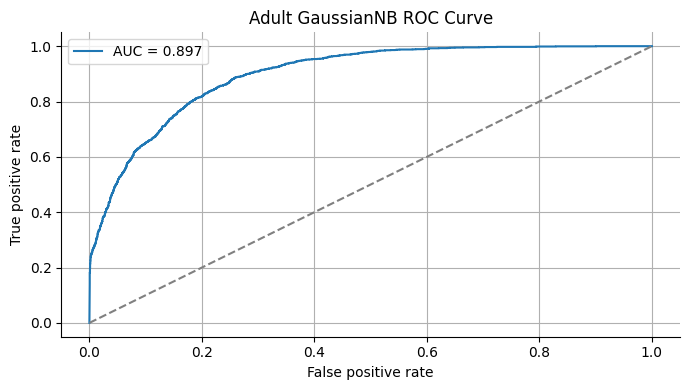

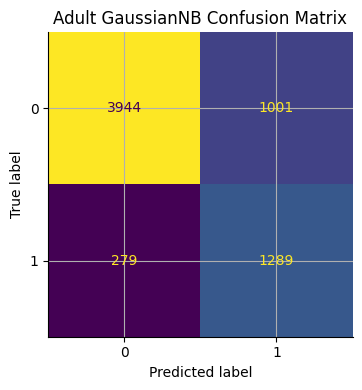

,p_gt50K,true_label,predicted_label
0,0.050473,0,0
1,0.000001,0,0
2,1.000000,1,1
3,0.980466,1,1
4,0.029150,0,0
5,0.000004,0,0
6,0.000005,0,0
7,0.999998,0,1
8,0.884952,0,1
9,0.906266,0,1


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

ADULT_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "Marital status", "occupation", "relationship", "race", "sex",
    "capitalgain", "capitalloss", "hoursperweek", "native", "Salary",
]

adult = pd.read_csv(ADULT_URL, header=None, names=col_names, na_values=["?", " ?", ""])
for column in adult.select_dtypes(include="object").columns:
    adult[column] = adult[column].str.strip()

X = adult.drop(columns="Salary")
y = adult["Salary"].map({"<=50K": 0, ">50K": 1, "<=50K.": 0, ">50K.": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

numeric_features = ["age", "fnlwgt", "education_num", "capitalgain", "capitalloss", "hoursperweek"]
categorical_features = ["workclass", "education", "Marital status", "occupation", "relationship", "race", "sex", "native"]

try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", one_hot)]), categorical_features),
    ]
)

X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

gnb = GaussianNB()
gnb.fit(X_train_t, y_train)

y_pred = gnb.predict(X_test_t)
y_proba = gnb.predict_proba(X_test_t)[:, 1]

adult_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
}
results["adult_nb"] = adult_metrics

print(pd.Series(adult_metrics).drop(labels=["confusion_matrix"]))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(np.array(adult_metrics["confusion_matrix"]))

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {adult_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Adult GaussianNB ROC Curve")
plt.legend()
save_current_plot("adult_nb_roc.png")
plt.show()

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Adult GaussianNB Confusion Matrix")
save_current_plot("adult_nb_confusion_matrix.png")
plt.show()

prob_df = pd.DataFrame({"p_gt50K": y_proba, "true_label": y_test.values, "predicted_label": y_pred})
display(prob_df.head(10))


The model is simple, but the preprocessing makes it a fair baseline. One-hot encoding prevents unordered categories from being treated as numeric ranks, robust scaling reduces the influence of heavy-tailed numeric fields, and probability outputs support ROC/AUC analysis in addition to hard-label metrics.


## Part 2: Support Vector Machines on HTRU2 Pulsar Candidates

The pulsar dataset is imbalanced, with true pulsars forming the minority class. The workflow therefore reports the required accuracy grid while also keeping precision, recall, F1, confusion matrix, and ROC/AUC for the optimized model. Standard scaling is applied because SVM margins are sensitive to feature scale.


Dataset shape: (17898, 9)

Class counts:
target_class
0    16259
1     1639
Name: count, dtype: int64

Class percentages:
target_class
0    90.843
1     9.157
Name: count, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Mean of the integrated profile,17898.0,111.079968,25.652935,5.812500,100.929688,115.078125,127.085938,192.617188
Standard deviation of the integrated profile,17898.0,46.549532,6.843189,24.772042,42.376018,46.947479,51.023202,98.778911
Excess kurtosis of the integrated profile,17898.0,0.477857,1.064040,-1.876011,0.027098,0.223240,0.473325,8.069522
Skewness of the integrated profile,17898.0,1.770279,6.167913,-1.791886,-0.188572,0.198710,0.927783,68.101622
Mean of the DM-SNR curve,17898.0,12.614400,29.472897,0.213211,1.923077,2.801839,5.464256,223.392141
Standard deviation of the DM-SNR curve,17898.0,26.326515,19.470572,7.370432,14.437332,18.461316,28.428104,110.642211
Excess kurtosis of the DM-SNR curve,17898.0,8.303556,4.506092,-3.139270,5.781506,8.433515,10.702959,34.539844
Skewness of the DM-SNR curve,17898.0,104.857709,106.514540,-1.976976,34.960504,83.064556,139.309330,1191.000837
target_class,17898.0,0.091574,0.288432,0.000000,0.000000,0.000000,0.000000,1.000000


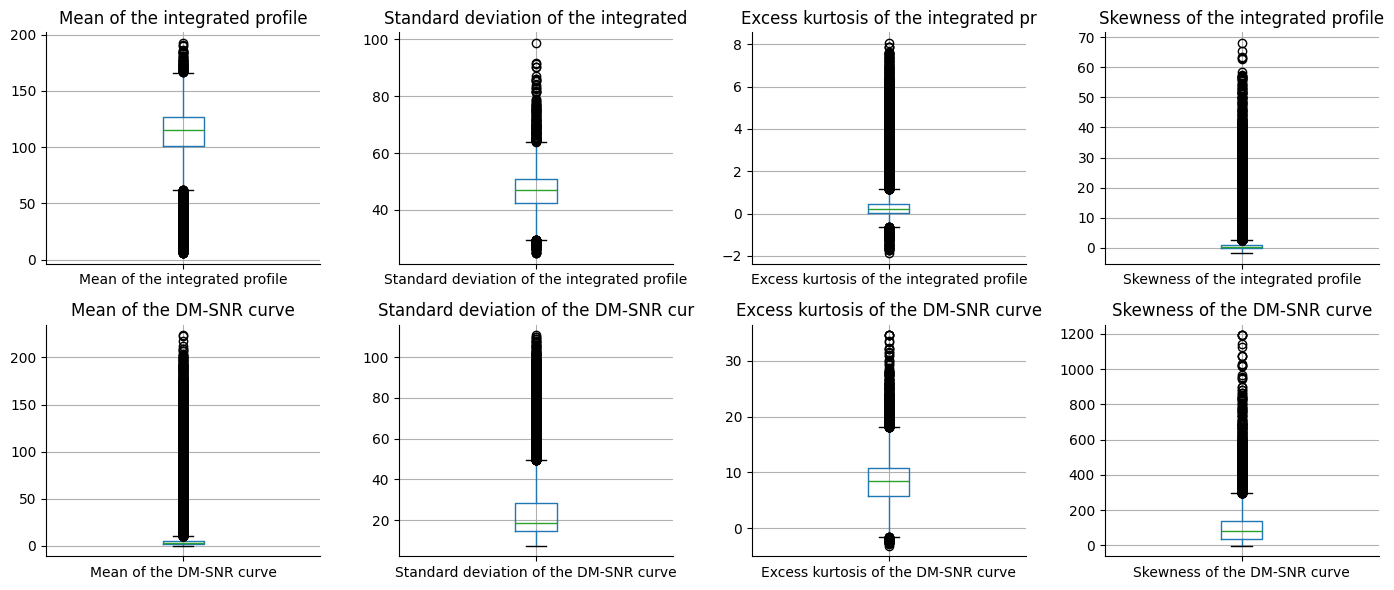

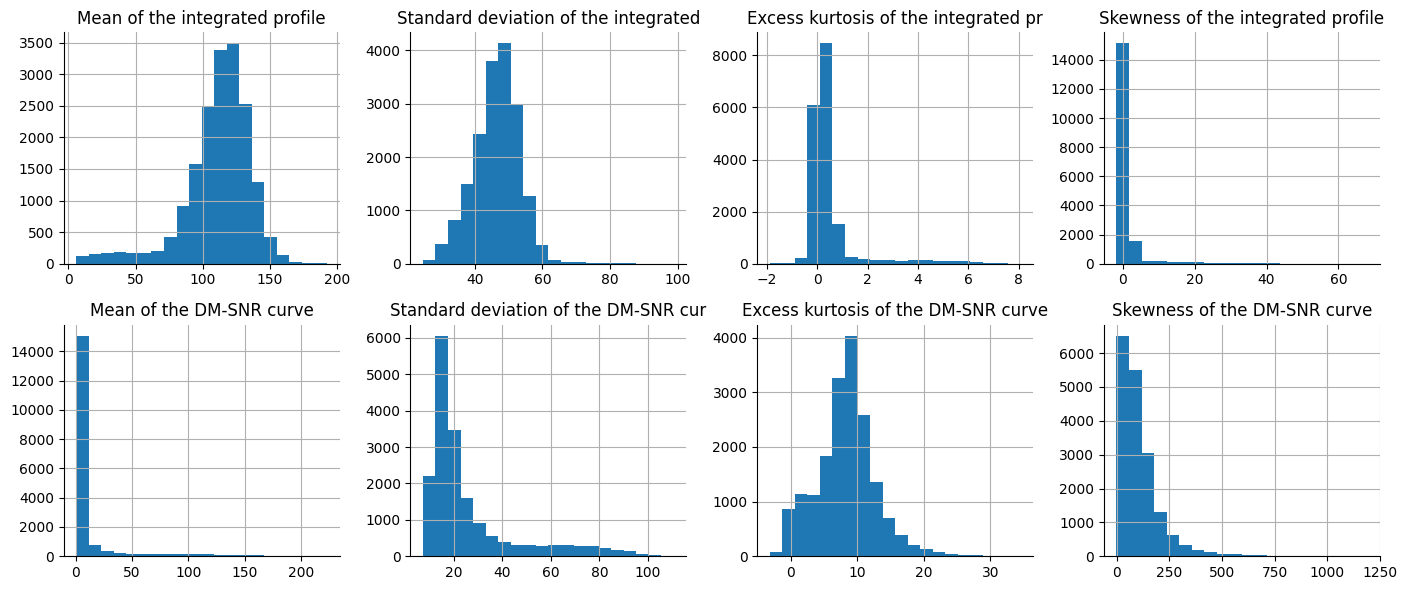

,kernel,C,test_accuracy
2,rbf,100,0.981285
1,rbf,10,0.981006
0,rbf,1,0.980726
5,linear,100,0.980168
3,linear,1,0.979888
4,linear,10,0.979888
8,poly,100,0.979888
7,poly,10,0.979330
6,poly,1,0.977933
10,sigmoid,10,0.877374


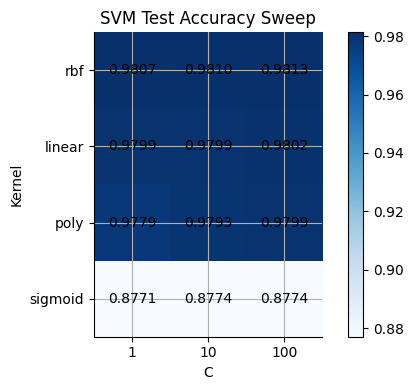

Best CV accuracy: 0.9796760200033168
Best params: {'C': 10, 'kernel': 'rbf'}
best_cv_accuracy    0.979676
test_accuracy       0.981006
precision           0.936242
recall              0.850610
f1                  0.891374
roc_auc             0.941716
dtype: float64


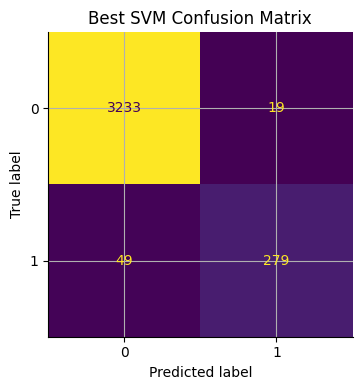

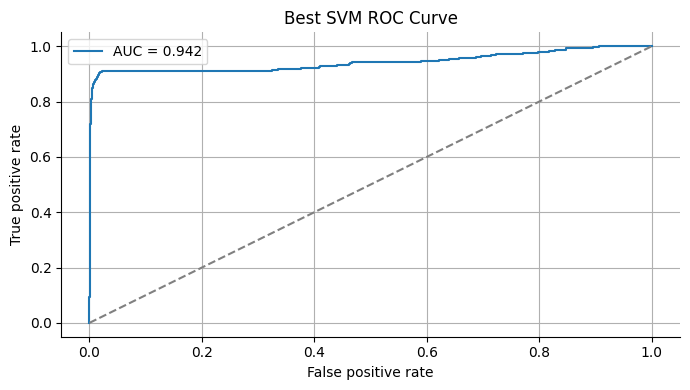

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

PULSAR_PATH = Path("pulsar_stars-1.csv")
if not PULSAR_PATH.exists():
    raise FileNotFoundError("pulsar_stars-1.csv must be in the same directory as the notebook")

pulsar = pd.read_csv(PULSAR_PATH)
pulsar.columns = [column.strip() for column in pulsar.columns]

feature_cols = [column for column in pulsar.columns if column != "target_class"]
Xp = pulsar[feature_cols]
yp = pulsar["target_class"]

class_counts = yp.value_counts().sort_index()
class_percent = (class_counts / len(yp) * 100).round(3)
results["pulsar_data"] = {
    "rows": int(len(pulsar)),
    "features": int(len(feature_cols)),
    "class_counts": {str(k): int(v) for k, v in class_counts.items()},
    "class_percent": {str(k): float(v) for k, v in class_percent.items()},
}

print("Dataset shape:", pulsar.shape)
print("\nClass counts:")
print(class_counts)
print("\nClass percentages:")
print(class_percent)
display(pulsar.describe().T)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, column in zip(axes.ravel(), feature_cols):
    pulsar.boxplot(column=column, ax=ax)
    ax.set_title(column[:36])
save_current_plot("pulsar_boxplots.png")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, column in zip(axes.ravel(), feature_cols):
    pulsar[column].hist(bins=20, ax=ax)
    ax.set_title(column[:36])
save_current_plot("pulsar_histograms.png")
plt.show()

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    Xp, yp, test_size=0.2, random_state=SEED, stratify=yp
)

scaler = StandardScaler()
Xp_train_s = scaler.fit_transform(Xp_train)
Xp_test_s = scaler.transform(Xp_test)

kernels = ["rbf", "linear", "poly", "sigmoid"]
C_vals = [1, 10, 100]

svm_rows = []
for kernel in kernels:
    for C in C_vals:
        model = SVC(kernel=kernel, C=C, probability=False, random_state=SEED)
        model.fit(Xp_train_s, yp_train)
        acc = accuracy_score(yp_test, model.predict(Xp_test_s))
        svm_rows.append({"kernel": kernel, "C": C, "test_accuracy": acc})

svm_sweep = pd.DataFrame(svm_rows).sort_values("test_accuracy", ascending=False)
results["svm_sweep"] = svm_sweep.to_dict(orient="records")
display(svm_sweep)

svm_pivot = svm_sweep.pivot(index="kernel", columns="C", values="test_accuracy").loc[kernels, C_vals]
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(svm_pivot.values, cmap="Blues", vmin=svm_pivot.values.min(), vmax=svm_pivot.values.max())
ax.set_xticks(range(len(C_vals)), C_vals)
ax.set_yticks(range(len(kernels)), kernels)
ax.set_xlabel("C")
ax.set_ylabel("Kernel")
ax.set_title("SVM Test Accuracy Sweep")
for i in range(len(kernels)):
    for j in range(len(C_vals)):
        ax.text(j, i, f"{svm_pivot.iloc[i, j]:.4f}", ha="center", va="center")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_current_plot("svm_accuracy_sweep.png")
plt.show()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
param_grid = {"kernel": kernels, "C": C_vals}

grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=SEED),
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid.fit(Xp_train_s, yp_train)

best_svm = grid.best_estimator_
yp_pred = best_svm.predict(Xp_test_s)
yp_proba = best_svm.predict_proba(Xp_test_s)[:, 1]

svm_metrics = {
    "best_cv_accuracy": grid.best_score_,
    "best_params": grid.best_params_,
    "test_accuracy": accuracy_score(yp_test, yp_pred),
    "precision": precision_score(yp_test, yp_pred, zero_division=0),
    "recall": recall_score(yp_test, yp_pred, zero_division=0),
    "f1": f1_score(yp_test, yp_pred, zero_division=0),
    "roc_auc": roc_auc_score(yp_test, yp_proba),
    "confusion_matrix": confusion_matrix(yp_test, yp_pred).tolist(),
}
results["svm_best"] = svm_metrics

print("Best CV accuracy:", svm_metrics["best_cv_accuracy"])
print("Best params:", svm_metrics["best_params"])
print(pd.Series({k: v for k, v in svm_metrics.items() if k not in ["best_params", "confusion_matrix"]}))

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(yp_test, yp_pred, ax=ax, colorbar=False)
ax.set_title("Best SVM Confusion Matrix")
save_current_plot("svm_confusion_matrix.png")
plt.show()

fpr, tpr, _ = roc_curve(yp_test, yp_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {svm_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Best SVM ROC Curve")
plt.legend()
save_current_plot("svm_roc.png")
plt.show()


The manual sweep gives a direct comparison across the required kernel and `C` values. `GridSearchCV` then repeats the search on training folds only, selects the best hyperparameters by accuracy, and evaluates the refit model once on the held-out test split.


## Part 3: Four-Layer Feed-Forward MLP

The neural-network section uses the same normalized pulsar features as the SVM section. The architecture has three ReLU hidden layers and one sigmoid output layer, which matches binary classification with `binary_crossentropy`. The grid search evaluates the required batch sizes, hidden-unit choices, and optimizers. The hyperparameter search uses a stratified tuning subset, the selected model is then trained for 100 epochs on the full training split with a 20% validation split.


MLP best CV accuracy: 0.9802500000000001
MLP best params: {'batch_size': 10, 'model__h1': 16, 'model__h2': 8, 'model__h3': 16, 'model__optimizer': 'adam'}
best_cv_accuracy       0.980250
test_accuracy          0.978492
precision              0.925424
recall                 0.832317
f1                     0.876404
roc_auc                0.967743
search_rows         4000.000000
dtype: float64


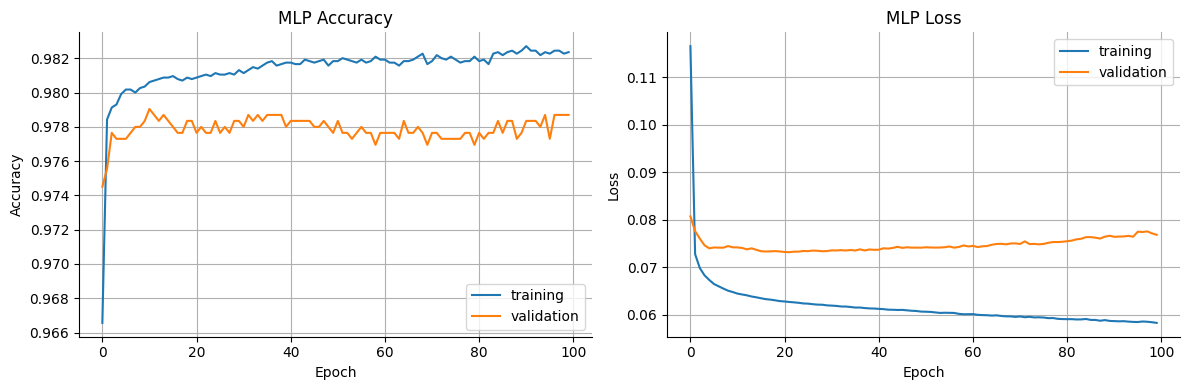

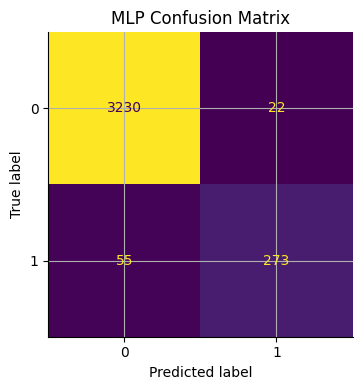

In [ ]:
import tensorflow as tf
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

tf.random.set_seed(SEED)
n_features = Xp_train_s.shape[1]


def build_mlp(meta=None, h1=8, h2=8, h3=8, optimizer="adam", dropout_rate=0.0):
    del meta
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(h1, activation="relu"),
        Dropout(dropout_rate),
        Dense(h2, activation="relu"),
        Dropout(dropout_rate),
        Dense(h3, activation="relu"),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

search_index, _ = train_test_split(
    np.arange(len(yp_train)),
    train_size=min(4000, len(yp_train)),
    random_state=SEED,
    stratify=yp_train,
)
X_mlp_search = Xp_train_s[search_index]
y_mlp_search = yp_train.iloc[search_index].to_numpy()

param_grid_mlp = {
    "batch_size": [10, 20],
    "model__optimizer": ["adam", "sgd"],
    "model__h1": [8, 16],
    "model__h2": [8, 16],
    "model__h3": [8, 16],
}
cv_mlp = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)


def run_mlp_grid(dropout_rate: float, label: str):
    clf = KerasClassifier(model=build_mlp, verbose=0, random_state=SEED, model__dropout_rate=dropout_rate)
    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid_mlp,
        scoring="accuracy",
        cv=cv_mlp,
        n_jobs=1,
        refit=True,
    )
    grid_search.fit(X_mlp_search, y_mlp_search, epochs=15, verbose=0)
    print(f"{label} best CV accuracy:", grid_search.best_score_)
    print(f"{label} best params:", grid_search.best_params_)
    return grid_search

mlp_grid = run_mlp_grid(0.0, "MLP")
best_params = mlp_grid.best_params_
final_mlp = build_mlp(
    h1=best_params["model__h1"],
    h2=best_params["model__h2"],
    h3=best_params["model__h3"],
    optimizer=best_params["model__optimizer"],
    dropout_rate=0.0,
)

history = final_mlp.fit(
    Xp_train_s,
    yp_train,
    epochs=100,
    validation_split=0.2,
    batch_size=best_params["batch_size"],
    verbose=0,
)

mlp_proba = final_mlp.predict(Xp_test_s, verbose=0).ravel()
mlp_pred = (mlp_proba >= 0.5).astype(int)

mlp_metrics = {
    "best_cv_accuracy": mlp_grid.best_score_,
    "best_params": mlp_grid.best_params_,
    "test_accuracy": accuracy_score(yp_test, mlp_pred),
    "precision": precision_score(yp_test, mlp_pred, zero_division=0),
    "recall": recall_score(yp_test, mlp_pred, zero_division=0),
    "f1": f1_score(yp_test, mlp_pred, zero_division=0),
    "roc_auc": roc_auc_score(yp_test, mlp_proba),
    "confusion_matrix": confusion_matrix(yp_test, mlp_pred).tolist(),
    "search_rows": int(len(X_mlp_search)),
}
results["mlp"] = mlp_metrics

print(pd.Series({k: v for k, v in mlp_metrics.items() if k not in ["best_params", "confusion_matrix"]}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="training")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("MLP Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[1].plot(history.history["loss"], label="training")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("MLP Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
save_current_plot("mlp_learning_curves.png")
plt.show()

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(yp_test, mlp_pred, ax=ax, colorbar=False)
ax.set_title("MLP Confusion Matrix")
save_current_plot("mlp_confusion_matrix.png")
plt.show()


## MLP With Dropout

The dropout version repeats the same search and final-training process, but inserts `Dropout(0.1)` after each hidden block. Dropout is useful here because the pulsar dataset is tabular and moderately imbalanced, so a small amount of regularization can reduce overly confident fits to the majority pattern.


MLP with dropout best CV accuracy: 0.98
MLP with dropout best params: {'batch_size': 10, 'model__h1': 16, 'model__h2': 16, 'model__h3': 8, 'model__optimizer': 'adam'}
best_cv_accuracy       0.980000
test_accuracy          0.979888
precision              0.910256
recall                 0.865854
f1                     0.887500
roc_auc                0.969835
search_rows         4000.000000
dtype: float64


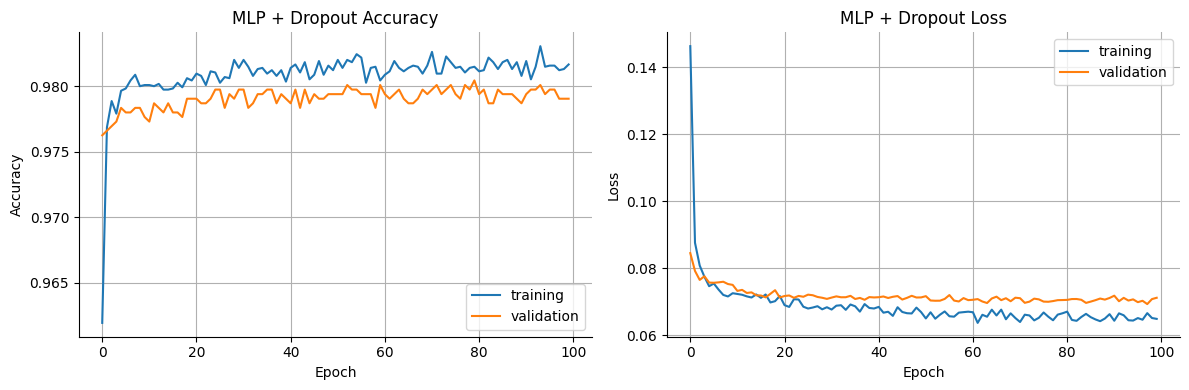

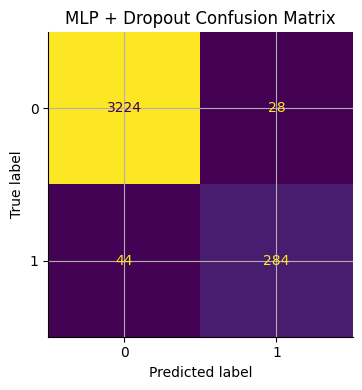

In [ ]:
mlp_do_grid = run_mlp_grid(0.1, "MLP with dropout")
best_do_params = mlp_do_grid.best_params_
final_mlp_do = build_mlp(
    h1=best_do_params["model__h1"],
    h2=best_do_params["model__h2"],
    h3=best_do_params["model__h3"],
    optimizer=best_do_params["model__optimizer"],
    dropout_rate=0.1,
)

history_do = final_mlp_do.fit(
    Xp_train_s,
    yp_train,
    epochs=100,
    validation_split=0.2,
    batch_size=best_do_params["batch_size"],
    verbose=0,
)

mlp_do_proba = final_mlp_do.predict(Xp_test_s, verbose=0).ravel()
mlp_do_pred = (mlp_do_proba >= 0.5).astype(int)

mlp_do_metrics = {
    "best_cv_accuracy": mlp_do_grid.best_score_,
    "best_params": mlp_do_grid.best_params_,
    "test_accuracy": accuracy_score(yp_test, mlp_do_pred),
    "precision": precision_score(yp_test, mlp_do_pred, zero_division=0),
    "recall": recall_score(yp_test, mlp_do_pred, zero_division=0),
    "f1": f1_score(yp_test, mlp_do_pred, zero_division=0),
    "roc_auc": roc_auc_score(yp_test, mlp_do_proba),
    "confusion_matrix": confusion_matrix(yp_test, mlp_do_pred).tolist(),
    "search_rows": int(len(X_mlp_search)),
}
results["mlp_dropout"] = mlp_do_metrics

print(pd.Series({k: v for k, v in mlp_do_metrics.items() if k not in ["best_params", "confusion_matrix"]}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_do.history["accuracy"], label="training")
axes[0].plot(history_do.history["val_accuracy"], label="validation")
axes[0].set_title("MLP + Dropout Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[1].plot(history_do.history["loss"], label="training")
axes[1].plot(history_do.history["val_loss"], label="validation")
axes[1].set_title("MLP + Dropout Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
save_current_plot("mlp_dropout_learning_curves.png")
plt.show()

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(yp_test, mlp_do_pred, ax=ax, colorbar=False)
ax.set_title("MLP + Dropout Confusion Matrix")
save_current_plot("mlp_dropout_confusion_matrix.png")
plt.show()


## (Optional): One-Sample Manual SGD Update

This builds a small sigmoid network with mean squared error and SGD at learning rate 0.1. The first layer starts at zero, the hidden-to-output layer starts at one, and the network trains on exactly the first training example for one epoch. The manually computed update uses the same forward pass and Keras MSE convention, so the Keras and NumPy weights would agree up to floating-point precision.


In [ ]:
from tensorflow.keras.initializers import Constant
from tensorflow.keras.optimizers import SGD

x0 = Xp_train_s[0:1].astype(np.float32)
y0 = yp_train.iloc[0:1].to_numpy(dtype=np.float32).reshape(1, 1)

print("First normalized training point:")
print(pd.DataFrame(x0, columns=feature_cols))
print("First training label:", int(y0[0, 0]))

hidden_units = 4
manual_model = Sequential([
    Input(shape=(n_features,)),
    Dense(hidden_units, activation="sigmoid", kernel_initializer=Constant(0.0), bias_initializer=Constant(0.0)),
    Dense(1, activation="sigmoid", kernel_initializer=Constant(1.0), bias_initializer=Constant(1.0)),
])
manual_model.compile(optimizer=SGD(learning_rate=0.1), loss="mse")

before = [w.copy() for w in manual_model.get_weights()]
manual_model.fit(x0, y0, epochs=1, batch_size=1, verbose=0)
after_keras = manual_model.get_weights()

W1, b1, W2, b2 = [w.copy() for w in before]
z1 = x0 @ W1 + b1
a1 = 1 / (1 + np.exp(-z1))
z2 = a1 @ W2 + b2
a2 = 1 / (1 + np.exp(-z2))

delta2 = (2 * (a2 - y0)) * (a2 * (1 - a2))
dW2 = a1.T @ delta2
db2 = np.sum(delta2, axis=0)
delta1 = (delta2 @ W2.T) * (a1 * (1 - a1))
dW1 = x0.T @ delta1
db1 = np.sum(delta1, axis=0)

lr = 0.1
manual_after = [W1 - lr * dW1, b1 - lr * db1, W2 - lr * dW2, b2 - lr * db2]
diffs = [float(np.max(np.abs(k - m))) for k, m in zip(after_keras, manual_after)]

optional_metrics = {
    "max_abs_diff_W1": diffs[0],
    "max_abs_diff_b1": diffs[1],
    "max_abs_diff_W2": diffs[2],
    "max_abs_diff_b2": diffs[3],
}
results["optional_manual_update"] = optional_metrics

print(pd.Series(optional_metrics))

results_path = ARTIFACT_DIR / "results.json"
with results_path.open("w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)
print(f"Saved metrics to {results_path}")


First normalized training point:
   Mean of the integrated profile  \
0                       -2.679468   

   Standard deviation of the integrated profile  \
0                                      -1.79478   

   Excess kurtosis of the integrated profile  \
0                                   2.859542   

   Skewness of the integrated profile  Mean of the DM-SNR curve  \
0                            2.736438                  2.311142   

   Standard deviation of the DM-SNR curve  \
0                                2.342991   

   Excess kurtosis of the DM-SNR curve  Skewness of the DM-SNR curve  
0                            -1.705896                     -0.990758  
First training label: 1
max_abs_diff_W1    0.0
max_abs_diff_b1    0.0
max_abs_diff_W2    0.0
max_abs_diff_b2    0.0
dtype: float64
Saved metrics to hw4_artifacts/results.json


Differences near machine precision indicate that the manual gradients match the library update. This closes the gap between the lecture equations and the `get_weights()` values returned by Keras after one SGD step.
